# 1.2 SPOC mechanism-aligned transfer benchmark

This notebook mirrors notebook **1.1** using the official-like SPOC reaction
representation while preserving the same controlled transfer question.

The target domain is fixed as inner-sphere Ru-AHO. Three predictive settings
are evaluated under the same five target folds and the same 11 classical
regressors:

1. target-only Ru-AHO;
2. mechanism-aligned transfer from inner-sphere Ru-AHK;
3. mechanism-mismatched transfer from outer-sphere Ru-AHK.

For each transfer source, mixed transfer and delta learning are both evaluated.
Pooled out-of-fold R² is the primary metric; MAE and RMSE are reported as
supporting metrics.

Outputs are written to:

`results/1_2_spoc_mechanism_transfer/`


In [1]:
from __future__ import annotations

import warnings
from collections import OrderedDict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from pandas.errors import EmptyDataError

from rdkit import Chem, RDLogger
from rdkit.Chem import Descriptors, MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray

from sklearn.ensemble import (
    AdaBoostRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
    RandomForestRegressor,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR, LinearSVR
from sklearn.tree import DecisionTreeRegressor, ExtraTreeRegressor

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "font.size": 10,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 9,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "svg.fonttype": "none",
    }
)

SOURCE_RULE_COLORS = {
    "target_only": "#7A7A7A",
    "mechanism_aligned": "#0072B2",
    "mechanism_mismatched": "#D55E00",
    "all_ru_ahk": "#7B61A8",
    "substrate_similar": "#009E73",
    "ligand_similar": "#E69F00",
    "reaction_feature_similar": "#56B4E9",
}
warnings.filterwarnings("ignore", category=ConvergenceWarning)
RDLogger.DisableLog("rdApp.warning")

RANDOM_STATE = 42
N_FOLDS = 5
PLOT_DPI = 300

# Keep result-level and feature-level caches separate.
# Recompute model predictions or SPOC descriptors only when intentionally requested.
FORCE_RECOMPUTE_RESULTS = False
FORCE_RECOMPUTE_FEATURES = False

TARGET_COLUMN = "ddG"
TARGET_COL_CANDIDATES = ["ddG", "DeltaDeltaG", "ΔΔG‡", "target", "Target", "y"]

COMPONENT_COLS = [
    "Reactant SMILES",
    "Product SMILES",
    "Ligand SMILES",
    "Solvent SMILES",
    "Additive SMILES",
]
CONDITION_COLS = ["Pressure/atm", "Temperature/C", "S/C"]


def find_project_root(start: Path | None = None) -> Path:
    """Find the repository root containing the canonical data/transfer directory."""
    start = Path.cwd() if start is None else Path(start)
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "transfer").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
TRANSFER_DOMAIN_ROOT = PROJECT_ROOT / "data" / "transfer"
OUT_DIR = PROJECT_ROOT / "results" / "1_2_spoc_mechanism_transfer"
TABLE_DIR = OUT_DIR / "tables"
FIG_DIR = OUT_DIR / "figures"
FEATURE_CACHE_DIR = OUT_DIR / "feature_cache"

for path in [TRANSFER_DOMAIN_ROOT, OUT_DIR, TABLE_DIR, FIG_DIR, FEATURE_CACHE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

OOF_PATH = TABLE_DIR / "spoc_ru_inner_outer_to_aho_inner_oof_predictions.csv"
SCORE_PATH = TABLE_DIR / "spoc_pooled_oof_metrics_long.csv"

# Keep the output directory lean. These files were written by earlier notebook versions,
# but they are not required for result reuse or manuscript figure generation.
CLEAN_OBSOLETE_OUTPUTS = True
OBSOLETE_OUTPUT_PATHS = [
    FEATURE_CACHE_DIR / "spoc_official_like_feature_columns.csv",
    FEATURE_CACHE_DIR / "spoc_official_like_feature_metadata.json",
    FEATURE_CACHE_DIR / "spoc_official_like_descriptor_table.csv",
    TABLE_DIR / "spoc_model_parameter_audit.csv",
    TABLE_DIR / "spoc_ru_domain_summary.csv",
    TABLE_DIR / "spoc_ru_inner_outer_to_aho_inner_errors.csv",
    FIG_DIR / "spoc_selected_models_pooled_oof_R2_heatmap_0_1.png",
    FIG_DIR / "spoc_selected_models_pooled_oof_R2_heatmap_0_1.pdf",
    FIG_DIR / "spoc_selected_best_parity_plots.png",
    FIG_DIR / "spoc_selected_best_parity_plots.pdf",
]

if CLEAN_OBSOLETE_OUTPUTS:
    for obsolete_path in OBSOLETE_OUTPUT_PATHS:
        if obsolete_path.exists():
            obsolete_path.unlink()


DOMAIN_FILES = OrderedDict(
    [
        ("ru_ahk_inner", TRANSFER_DOMAIN_ROOT / "ru_ahk_inner.csv"),
        ("ru_ahk_outer", TRANSFER_DOMAIN_ROOT / "ru_ahk_outer.csv"),
        ("ru_aho_inner", TRANSFER_DOMAIN_ROOT / "ru_aho_inner.csv"),
    ]
)

TRANSFER_TASKS = [
    {
        "task_id": "ru_ahk_inner_to_ru_aho_inner",
        "source_key": "ru_ahk_inner",
        "target_key": "ru_aho_inner",
        "source_domain": "inner",
        "target_domain": "inner",
        "relation_label": "Same mechanism",
        "scene_label": "Ru-AHK inner -> Ru-AHO inner",
    },
    {
        "task_id": "ru_ahk_outer_to_ru_aho_inner",
        "source_key": "ru_ahk_outer",
        "target_key": "ru_aho_inner",
        "source_domain": "outer",
        "target_domain": "inner",
        "relation_label": "Different mechanism",
        "scene_label": "Ru-AHK outer -> Ru-AHO inner",
    },
]

OOF_COLUMNS = [
    "descriptor",
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
    "fold_id",
    "target_index",
    "record_id",
    "reaction_id",
    "y_true",
    "y_pred",
]
ERROR_COLUMNS = ["model", "task_id", "method_label", "error"]


def read_csv_or_empty(path, columns=None):
    """Read a CSV cache safely, returning an empty table when the file has no parseable content."""
    if columns is None:
        columns = []
    path = Path(path)
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame(columns=columns)
    try:
        return pd.read_csv(path)
    except EmptyDataError:
        return pd.DataFrame(columns=columns)


def csv_has_data_rows(path, required_columns=None):
    """Return True only when a cached CSV has at least one row and the expected columns."""
    if required_columns is None:
        required_columns = []
    cache = read_csv_or_empty(path, columns=required_columns)
    if len(cache) == 0:
        return False
    missing = [col for col in required_columns if col not in cache.columns]
    return len(missing) == 0


RESULT_CACHE_AVAILABLE = csv_has_data_rows(OOF_PATH, required_columns=OOF_COLUMNS)
NEED_FEATURE_MATRICES = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

print(f"Project root: {PROJECT_ROOT}")
print(f"Transfer domain directory: {TRANSFER_DOMAIN_ROOT}")
print(f"Output directory: {OUT_DIR}")
print(f"Feature cache directory: {FEATURE_CACHE_DIR}")
print(f"Result cache available: {RESULT_CACHE_AVAILABLE}")
print(f"Feature matrices required in this run: {NEED_FEATURE_MATRICES}")


Project root: /home/syz/ru-mechanism-transfer
Transfer domain directory: /home/syz/ru-mechanism-transfer/data/transfer
Output directory: /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer
Feature cache directory: /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer/feature_cache
Result cache available: True
Feature matrices required in this run: False


## 1. Load the three canonical Ru domains

The notebook reads only the three curated transfer-domain files under `data/transfer/`. 


In [2]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")
    return path


def infer_target_column(df: pd.DataFrame) -> str:
    for col in TARGET_COL_CANDIDATES:
        if col in df.columns:
            return col
    for col in df.columns:
        low = str(col).lower()
        if "ddg" in low or "delta" in low:
            return col
    raise KeyError(f"Cannot infer target column from: {list(df.columns)}")


def canonicalize_smiles(value) -> str:
    if pd.isna(value):
        return ""
    smi = str(value).strip()
    if smi == "" or smi.lower() in {"nan", "none", "null"}:
        return ""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return smi
    try:
        return Chem.MolToSmiles(mol, canonical=True, isomericSmiles=True)
    except Exception:
        return smi


def load_domain_table(path: Path, domain_key: str, dataset: str, mechanism_domain: str, group_label: str) -> pd.DataFrame:
    df = pd.read_csv(require_file(path)).copy()
    y_col = infer_target_column(df)
    df[TARGET_COLUMN] = pd.to_numeric(df[y_col], errors="coerce")
    df = df.loc[df[TARGET_COLUMN].notna()].reset_index(drop=True)

    for col in COMPONENT_COLS:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].map(canonicalize_smiles)

    for col in CONDITION_COLS:
        if col not in df.columns:
            df[col] = np.nan
        df[col] = pd.to_numeric(df[col], errors="coerce")

    if "Metal" not in df.columns:
        df["Metal"] = "Ru"
    df["Metal"] = df["Metal"].fillna("Ru").astype(str).str.strip().str.capitalize()

    if "reaction_id" not in df.columns:
        df["reaction_id"] = [f"{domain_key}_{i:05d}" for i in range(len(df))]

    df["domain_key"] = domain_key
    df["group_key"] = domain_key
    df["group_label"] = group_label
    df["dataset"] = dataset
    df["mechanism_domain"] = mechanism_domain
    df["record_id"] = [f"{domain_key}__{i:05d}" for i in range(len(df))]
    return df


DOMAIN_SPECS = OrderedDict(
    [
        (
            "ru_ahk_inner",
            {
                "path": DOMAIN_FILES["ru_ahk_inner"],
                "domain_key": "ru_ahk_inner",
                "dataset": "AHK",
                "mechanism_domain": "inner",
                "group_label": "Source: Ru-AHK inner",
            },
        ),
        (
            "ru_ahk_outer",
            {
                "path": DOMAIN_FILES["ru_ahk_outer"],
                "domain_key": "ru_ahk_outer",
                "dataset": "AHK",
                "mechanism_domain": "outer",
                "group_label": "Source: Ru-AHK outer",
            },
        ),
        (
            "ru_aho_inner",
            {
                "path": DOMAIN_FILES["ru_aho_inner"],
                "domain_key": "ru_aho_inner",
                "dataset": "AHO",
                "mechanism_domain": "inner",
                "group_label": "Target: Ru-AHO inner",
            },
        ),
    ]
)

DOMAINS = OrderedDict((key, load_domain_table(**spec)) for key, spec in DOMAIN_SPECS.items())
ALL_DF = pd.concat(DOMAINS.values(), ignore_index=True)

DOMAIN_SUMMARY = pd.DataFrame(
    [
        {
            "domain_key": key,
            "path": str(DOMAIN_FILES[key].relative_to(PROJECT_ROOT)),
            "dataset": df["dataset"].iloc[0],
            "mechanism_domain": df["mechanism_domain"].iloc[0],
            "n_samples": len(df),
            "n_reactants": df["Reactant SMILES"].nunique(),
            "n_ligands": df["Ligand SMILES"].nunique() if "Ligand SMILES" in df.columns else np.nan,
            "ddG_mean": df[TARGET_COLUMN].mean(),
            "ddG_std": df[TARGET_COLUMN].std(),
        }
        for key, df in DOMAINS.items()
    ]
)
display(DOMAIN_SUMMARY)
print("Total samples:", len(ALL_DF))


,domain_key,path,dataset,mechanism_domain,n_samples,n_reactants,n_ligands,ddG_mean,ddG_std
0,ru_ahk_inner,data/transfer/ru_ahk_inner.csv,AHK,inner,495,214,41,2.077446,0.959506
1,ru_ahk_outer,data/transfer/ru_ahk_outer.csv,AHK,outer,1539,345,304,1.971399,0.865312
2,ru_aho_inner,data/transfer/ru_aho_inner.csv,AHO,inner,98,38,22,1.910037,0.950583


Total samples: 2132


## 2. Build or load cached SPOC feature matrix

Each reaction is represented by official-like SPOC features: MACCS keys and RDKit molecular descriptors for reactant, product, ligand, solvent, and additive, followed by numeric reaction-condition features and light reaction-context labels.

The computed matrix is cached under `feature_cache/` as a single file:

- `spoc_official_like_feature_matrix.npy`

The feature-column names are reconstructed in memory from the same deterministic descriptor definition. The cache is reused only when the matrix shape matches the current input rows and feature definition. If descriptor settings or input ordering are intentionally changed, set `FORCE_RECOMPUTE_FEATURES = True` once to rebuild the matrix.


In [3]:
DESC_LIST = list(Descriptors._descList)
DESC_NAMES = [name for name, _ in DESC_LIST]
MACCS_N_BITS = 167
SPOC_DESCRIPTOR_VERSION = "spoc_official_like_maccs_rdkit_conditions_labels_v2"
SPOC_MATRIX_CACHE_PATH = FEATURE_CACHE_DIR / "spoc_official_like_feature_matrix.npy"

SPOC_COMPONENT_PREFIXES = OrderedDict(
    [
        ("Reactant SMILES", "reactant"),
        ("Product SMILES", "product"),
        ("Ligand SMILES", "ligand"),
        ("Solvent SMILES", "solvent"),
        ("Additive SMILES", "additive"),
    ]
)


def smiles_to_mol(smiles: str):
    if smiles is None or str(smiles).strip() == "":
        return None
    try:
        return Chem.MolFromSmiles(str(smiles))
    except Exception:
        return None


def maccs_array(mol) -> np.ndarray:
    arr = np.zeros((MACCS_N_BITS,), dtype=np.float32)
    if mol is None:
        return arr
    try:
        fp = MACCSkeys.GenMACCSKeys(mol)
        ConvertToNumpyArray(fp, arr)
    except Exception:
        arr[:] = np.nan
    return arr


def rdkit_descriptor_array(mol) -> np.ndarray:
    vals = []
    for _, fn in DESC_LIST:
        if mol is None:
            vals.append(np.nan)
            continue
        try:
            vals.append(float(fn(mol)))
        except Exception:
            vals.append(np.nan)
    return np.asarray(vals, dtype=np.float32)


def build_component_spoc(df: pd.DataFrame, col: str, prefix: str) -> pd.DataFrame:
    maccs_rows = []
    desc_rows = []
    for smi in df[col].astype(str).tolist():
        mol = smiles_to_mol(smi)
        maccs_rows.append(maccs_array(mol))
        desc_rows.append(rdkit_descriptor_array(mol))

    maccs_df = pd.DataFrame(
        np.vstack(maccs_rows),
        columns=[f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_N_BITS)],
        index=df.index,
    )
    desc_df = pd.DataFrame(
        np.vstack(desc_rows),
        columns=[f"{prefix}__RDKit_{name}" for name in DESC_NAMES],
        index=df.index,
    )
    return pd.concat([maccs_df, desc_df], axis=1)


def expected_spoc_feature_columns(df: pd.DataFrame) -> list[str]:
    columns = []
    for _, prefix in SPOC_COMPONENT_PREFIXES.items():
        columns.extend([f"{prefix}__MACCS_{i:03d}" for i in range(MACCS_N_BITS)])
        columns.extend([f"{prefix}__RDKit_{name}" for name in DESC_NAMES])

    columns.extend([f"condition__{col}" for col in CONDITION_COLS])

    label_columns = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    ).columns.astype(str).tolist()
    columns.extend(label_columns)
    return columns


def build_spoc_matrix(df: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    pieces = []
    for col, prefix in SPOC_COMPONENT_PREFIXES.items():
        print(f"Building SPOC component descriptors: {prefix}")
        pieces.append(build_component_spoc(df, col, prefix))

    # Numeric reaction conditions are included directly and imputed inside CV pipelines.
    condition_df = df[CONDITION_COLS].apply(pd.to_numeric, errors="coerce")
    condition_df.columns = [f"condition__{c}" for c in condition_df.columns]
    pieces.append(condition_df)

    # Reaction-context labels: keep them light and reproducible.
    label_df = pd.get_dummies(
        df[["Metal", "Solvent SMILES", "Additive SMILES"]].fillna("Unknown").astype(str),
        prefix=["label__Metal", "label__Solvent", "label__Additive"],
        dtype=np.float32,
    )
    pieces.append(label_df)

    x_df = pd.concat(pieces, axis=1).replace([np.inf, -np.inf], np.nan)
    return x_df.to_numpy(dtype=np.float32), list(x_df.columns)


def load_cached_spoc_matrix(expected_columns: list[str]):
    if FORCE_RECOMPUTE_FEATURES or not SPOC_MATRIX_CACHE_PATH.exists():
        return None, None
    try:
        matrix = np.load(SPOC_MATRIX_CACHE_PATH)
        expected_shape = (len(ALL_DF), len(expected_columns))
        if matrix.shape != expected_shape:
            print(f"Cached SPOC matrix has shape {matrix.shape}, expected {expected_shape}; rebuilding.")
            return None, None
        print(f"Loaded cached SPOC features: {matrix.shape}")
        return matrix.astype(np.float32, copy=False), expected_columns
    except Exception as exc:
        print(f"Could not load cached SPOC features: {exc!r}; rebuilding.")
        return None, None


def save_cached_spoc_matrix(matrix):
    matrix = matrix.astype(np.float32, copy=False)
    np.save(SPOC_MATRIX_CACHE_PATH, matrix)
    print(f"Saved SPOC feature cache: {SPOC_MATRIX_CACHE_PATH}")


TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())
TARGET_META = OrderedDict(
    (
        key,
        df[["record_id", "reaction_id", "domain_key", "group_key"]].reset_index(drop=True),
    )
    for key, df in DOMAINS.items()
)
FEATURES = OrderedDict()

if NEED_FEATURE_MATRICES:
    EXPECTED_FEATURE_COLUMNS = expected_spoc_feature_columns(ALL_DF)
    X_MATRIX, FEATURE_COLUMNS = load_cached_spoc_matrix(EXPECTED_FEATURE_COLUMNS)
    if X_MATRIX is None:
        print(f"Building SPOC features for all Ru domains: {len(ALL_DF)} rows")
        X_MATRIX, FEATURE_COLUMNS = build_spoc_matrix(ALL_DF)
        if FEATURE_COLUMNS != EXPECTED_FEATURE_COLUMNS:
            raise RuntimeError("Reconstructed SPOC feature columns do not match the freshly built columns.")
        save_cached_spoc_matrix(X_MATRIX)

    start = 0
    for key, df in DOMAINS.items():
        stop = start + len(df)
        FEATURES[key] = X_MATRIX[start:stop].astype(np.float32, copy=False)
        start = stop

    print("X shape:", X_MATRIX.shape)
    print("NaN count:", int(np.isnan(X_MATRIX).sum()))
    display(pd.DataFrame(X_MATRIX[:3], columns=FEATURE_COLUMNS).iloc[:, :12])
else:
    print("OOF predictions are already cached. SPOC feature matrix is not loaded in this run.")


OOF predictions are already cached. SPOC feature matrix is not loaded in this run.


## 3. Selected classical model set

The model set is explicitly defined below and mirrors notebook 1.1. The only descriptor-specific difference is that SPOC pipelines include mean imputation before each estimator.


In [4]:
SPOC_MODEL_FACTORIES = OrderedDict(
    [
        # (
        #     "AdaBoostRegressor",
        #     lambda: make_pipeline(
        #         SimpleImputer(strategy="mean"),
        #         AdaBoostRegressor(random_state=RANDOM_STATE),
        #     ),
        # ),
        (
            "ExtraTreesRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                ExtraTreesRegressor(n_jobs=-1, random_state=RANDOM_STATE),
            ),
        ),
        (
            "GradientBoostingRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                GradientBoostingRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "HistGradientBoostingRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                HistGradientBoostingRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "RandomForestRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                RandomForestRegressor(n_jobs=-1, random_state=RANDOM_STATE),
            ),
        ),
        (
            "GaussianProcessRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                GaussianProcessRegressor(
                    normalize_y=True,
                    alpha=1e-6,
                    random_state=RANDOM_STATE,
                ),
            ),
        ),
        (
            "KNeighborsRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                KNeighborsRegressor(),
            ),
        ),
        (
            "SVR",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                SVR(),
            ),
        ),
        (
            "LinearSVR",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                StandardScaler(),
                LinearSVR(random_state=RANDOM_STATE, max_iter=5000),
            ),
        ),
        (
            "DecisionTreeRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                DecisionTreeRegressor(random_state=RANDOM_STATE),
            ),
        ),
        (
            "ExtraTreeRegressor",
            lambda: make_pipeline(
                SimpleImputer(strategy="mean"),
                ExtraTreeRegressor(random_state=RANDOM_STATE),
            ),
        ),
    ]
)


MODEL_KEYS_TO_RUN = list(SPOC_MODEL_FACTORIES.keys())

MODEL_AUDIT_DF = pd.DataFrame(
    [
        {
            "model": model_key,
            "factory_repr": repr(SPOC_MODEL_FACTORIES[model_key]()),
        }
        for model_key in MODEL_KEYS_TO_RUN
    ]
)
display(MODEL_AUDIT_DF)


,model,factory_repr
0,ExtraTreesRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
1,GradientBoostingRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
2,HistGradientBoostingRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
3,RandomForestRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
4,GaussianProcessRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
5,KNeighborsRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
6,SVR,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
7,LinearSVR,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
8,DecisionTreeRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."
9,ExtraTreeRegressor,"Pipeline(steps=[('simpleimputer', SimpleImpute..."


## 4. Run pooled out-of-fold transfer benchmarks

The target domain is always Ru-AHO inner. Two source-to-target tasks are evaluated:

1. Ru-AHK inner -> Ru-AHO inner, representing same-mechanism transfer.
2. Ru-AHK outer -> Ru-AHO inner, representing different-mechanism transfer.

For classical SPOC models, the transfer strategies are direct source-target mixing and source-prior delta learning. The target-only baseline is computed once for the Ru-AHO target domain.

If a valid OOF prediction table already exists, it is loaded directly and SPOC features are not rebuilt.


In [5]:
def make_model(model_key):
    return SPOC_MODEL_FACTORIES[model_key]()


def predict_1d(model, x):
    pred = np.asarray(model.predict(x)).reshape(-1)
    return pred.astype(float)


def kfold_splitter(y_target):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)


def run_target_only_oof(model_key, x_target, y_target, target_meta):
    rows = []
    cv = kfold_splitter(y_target)
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        model = make_model(model_key)
        model.fit(x_target[train_idx], y_target[train_idx])
        pred = predict_1d(model, x_target[test_idx])
        fold_meta = target_meta.iloc[test_idx].reset_index(drop=True)

        for i, local_idx in enumerate(test_idx):
            rows.append(
                {
                    "descriptor": "SPOC_official_like",
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "scene_label": "Ru-AHO inner target-only",
                    "source_domain": "none",
                    "target_domain": "inner",
                    "relation_label": "Target-only",
                    "method_label": "Target-only",
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "record_id": fold_meta.loc[i, "record_id"],
                    "reaction_id": fold_meta.loc[i, "reaction_id"],
                    "y_true": float(y_target[local_idx]),
                    "y_pred": float(pred[i]),
                }
            )
    return rows


def run_transfer_oof(model_key, task, x_source, y_source, x_target, y_target, target_meta):
    rows = []
    cv = kfold_splitter(y_target)

    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]
        fold_meta = target_meta.iloc[test_idx].reset_index(drop=True)

        mixed_model = make_model(model_key)
        x_mixed = np.vstack([x_source, x_train])
        y_mixed = np.concatenate([y_source, y_train])
        mixed_model.fit(x_mixed, y_mixed)
        pred_mixed = predict_1d(mixed_model, x_test)

        delta_model = make_model(model_key)
        source_prior_train = predict_1d(source_prior_model, x_train)
        delta_model.fit(x_train, y_train - source_prior_train)
        pred_delta = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)

        prediction_map = OrderedDict(
            [
                ("Mixed transfer", pred_mixed),
                ("Delta learning", pred_delta),
            ]
        )

        for method_label, pred in prediction_map.items():
            for i, local_idx in enumerate(test_idx):
                rows.append(
                    {
                        "descriptor": "SPOC_official_like",
                        "model": model_key,
                        "task_id": task["task_id"],
                        "scene_label": task["scene_label"],
                        "source_domain": task["source_domain"],
                        "target_domain": task["target_domain"],
                        "relation_label": task["relation_label"],
                        "method_label": method_label,
                        "fold_id": int(fold_id),
                        "target_index": int(local_idx),
                        "record_id": fold_meta.loc[i, "record_id"],
                        "reaction_id": fold_meta.loc[i, "reaction_id"],
                        "y_true": float(y_test[i]),
                        "y_pred": float(pred[i]),
                    }
                )
    return rows


RUN_MODELS = FORCE_RECOMPUTE_RESULTS or not RESULT_CACHE_AVAILABLE

if not RUN_MODELS:
    MULTI_MODEL_OOF_DF = read_csv_or_empty(OOF_PATH, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(columns=ERROR_COLUMNS)
    print(f"Loaded cached OOF predictions from {OOF_PATH}")
else:
    if not FEATURES:
        raise RuntimeError(
            "Feature matrices are required for recomputation but were not built. "
            "Set FORCE_RECOMPUTE_RESULTS=False to use cached predictions, or rerun the feature-cache cell."
        )

    all_rows = []
    error_rows = []
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]
    target_meta = TARGET_META["ru_aho_inner"]

    for model_key in MODEL_KEYS_TO_RUN:
        print(f"Running {model_key}")
        try:
            all_rows.extend(run_target_only_oof(model_key, x_target, y_target, target_meta))
        except Exception as exc:
            error_rows.append(
                {
                    "model": model_key,
                    "task_id": "target_only_ru_aho_inner",
                    "method_label": "Target-only",
                    "error": repr(exc),
                }
            )
            print(f"  Target-only failed for {model_key}: {exc!r}")

        for task in TRANSFER_TASKS:
            try:
                source_key = task["source_key"]
                all_rows.extend(
                    run_transfer_oof(
                        model_key,
                        task,
                        FEATURES[source_key],
                        TARGETS[source_key],
                        x_target,
                        y_target,
                        target_meta,
                    )
                )
            except Exception as exc:
                error_rows.append(
                    {
                        "model": model_key,
                        "task_id": task["task_id"],
                        "method_label": "transfer",
                        "error": repr(exc),
                    }
                )
                print(f"  Transfer failed for {model_key}, {task['task_id']}: {exc!r}")

    MULTI_MODEL_OOF_DF = pd.DataFrame(all_rows, columns=OOF_COLUMNS)
    ERROR_DF = pd.DataFrame(error_rows, columns=ERROR_COLUMNS)
    MULTI_MODEL_OOF_DF.to_csv(OOF_PATH, index=False)

print(f"OOF prediction rows: {len(MULTI_MODEL_OOF_DF)}")
if len(ERROR_DF):
    print("Some model-task combinations failed. The errors are shown below and are not written to disk.")
    display(ERROR_DF)


Loaded cached OOF predictions from /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer/tables/spoc_ru_inner_outer_to_aho_inner_oof_predictions.csv
OOF prediction rows: 4900


## 5. Summarize metrics and generate reviewer-facing figures

Pooled OOF metrics are computed after concatenating predictions from all target folds. The heatmap and parity plots use the same column order, target-only handling, and panel logic as notebook 1.1, so MFF and SPOC figures can be pasted together cleanly in the manuscript.


,descriptor,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total
26,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.702908,0.352521,0.515476,98
11,SPOC_official_like,ExtraTreesRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.681813,0.367103,0.533463,98
41,SPOC_official_like,RandomForestRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.664338,0.390338,0.547916,98
43,SPOC_official_like,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.649806,0.394406,0.559651,98
27,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Delta learning,0.637656,0.434750,0.569277,98
20,SPOC_official_like,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Delta learning,0.636471,0.398876,0.570207,98
21,SPOC_official_like,GradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.630314,0.414097,0.575015,98
24,SPOC_official_like,GradientBoostingRegressor,target_only_ru_aho_inner,Ru-AHO inner target-only,none,inner,Target-only,Target-only,0.621655,0.405804,0.581710,98
42,SPOC_official_like,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Delta learning,0.618166,0.407563,0.584386,98
28,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.616949,0.417863,0.585317,98


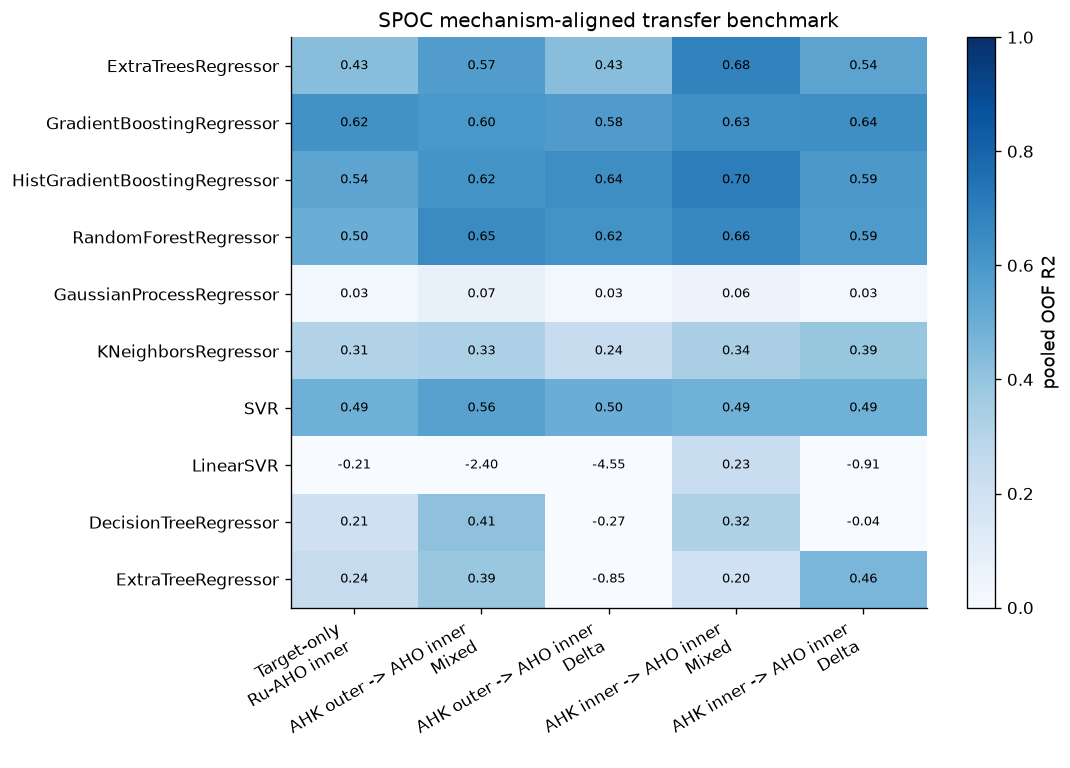

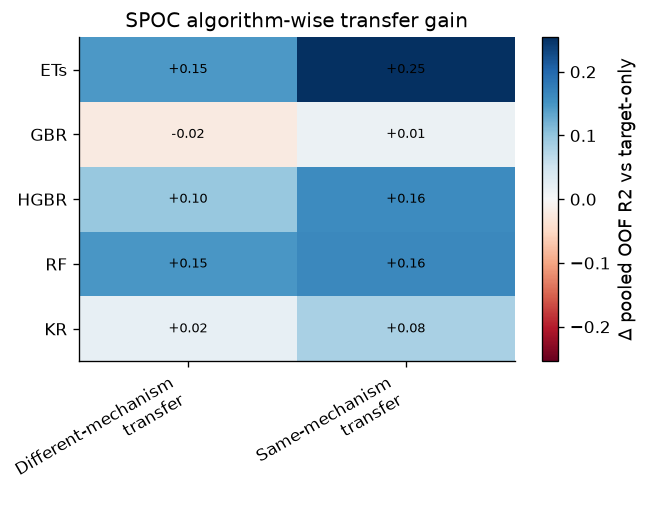

In [6]:
def pooled_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[finite]
    y_pred = y_pred[finite]
    return {
        "R2": float(r2_score(y_true, y_pred)) if len(y_true) >= 2 else np.nan,
        "MAE": float(mean_absolute_error(y_true, y_pred)) if len(y_true) else np.nan,
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))) if len(y_true) else np.nan,
        "n_test_total": int(len(y_true)),
    }


GROUP_COLUMNS = [
    "descriptor",
    "model",
    "task_id",
    "scene_label",
    "source_domain",
    "target_domain",
    "relation_label",
    "method_label",
]

metric_rows = []
for keys, group in MULTI_MODEL_OOF_DF.groupby(GROUP_COLUMNS, dropna=False):
    row = dict(zip(GROUP_COLUMNS, keys))
    row.update(pooled_metrics(group["y_true"].to_numpy(), group["y_pred"].to_numpy()))
    metric_rows.append(row)

MULTI_MODEL_SCORE_LONG = pd.DataFrame(metric_rows)
MULTI_MODEL_SCORE_LONG.to_csv(SCORE_PATH, index=False)
display(MULTI_MODEL_SCORE_LONG.sort_values("R2", ascending=False))


def plot_column_label(row):
    if row["method_label"] == "Target-only":
        return "Target-only\nRu-AHO inner"
    method_short = {"Mixed transfer": "Mixed", "Delta learning": "Delta"}.get(
        row["method_label"], row["method_label"]
    )
    source_short = "AHK inner" if row["source_domain"] == "inner" else "AHK outer"
    return f"{source_short} -> AHO inner\n{method_short}"


plot_score = MULTI_MODEL_SCORE_LONG.copy()
plot_score["plot_col"] = plot_score.apply(plot_column_label, axis=1)

# Keep the full benchmark heatmap, but place different-mechanism transfer
# before same-mechanism transfer throughout the figure.
HEATMAP_COLUMN_ORDER = [
    "Target-only\nRu-AHO inner",
    "AHK outer -> AHO inner\nMixed",
    "AHK outer -> AHO inner\nDelta",
    "AHK inner -> AHO inner\nMixed",
    "AHK inner -> AHO inner\nDelta",
]

R2_HEATMAP = (
    plot_score.pivot_table(index="model", columns="plot_col", values="R2", aggfunc="mean")
    .reindex(index=MODEL_KEYS_TO_RUN)
    .reindex(columns=[col for col in HEATMAP_COLUMN_ORDER if col in plot_score["plot_col"].unique()])
)
R2_HEATMAP.to_csv(TABLE_DIR / "spoc_pooled_oof_r2_heatmap_table.csv")


def plot_annotated_heatmap(table, out_path, title, cbar_label="pooled OOF R2"):
    values = table.to_numpy(dtype=float)
    color_values = np.clip(values, 0.0, 1.0)
    masked_values = np.ma.masked_invalid(color_values)

    fig_w = max(7.2, 1.45 * table.shape[1] + 2.0)
    fig_h = max(4.2, 0.48 * table.shape[0] + 1.7)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(masked_values, aspect="auto", cmap="Blues", vmin=0.0, vmax=1.0)

    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_title(title)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(
                    j,
                    i,
                    f"{float(value):.2f}",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black",
                )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(cbar_label)
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


# Original full heatmap retained.
plot_annotated_heatmap(
    R2_HEATMAP,
    FIG_DIR / "spoc_selected_models_pooled_oof_R2_heatmap_0_1.svg",
    "SPOC mechanism-aligned transfer benchmark",
    "pooled OOF R2",
)


# Compact heatmap for the main-text comparison.
# Mixed transfer and delta learning are collapsed by taking the higher R2
# within each mechanism relation for each model.
COMPACT_HEATMAP_MODELS = OrderedDict(
    [
        ("ExtraTreesRegressor", "ETs"),
        ("GradientBoostingRegressor", "GBR"),
        ("HistGradientBoostingRegressor", "HGBR"),
        ("RandomForestRegressor", "RF"),
        ("KNeighborsRegressor", "KR"),
    ]
)


def best_transfer_r2(score_long, model_key, relation_label):
    sub = score_long.loc[
        score_long["model"].eq(model_key)
        & score_long["relation_label"].eq(relation_label)
        & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
    ].copy()
    if len(sub) == 0:
        return np.nan
    return float(sub["R2"].max())


transfer_gain_rows = []
for model_key, short_label in COMPACT_HEATMAP_MODELS.items():
    baseline_sub = MULTI_MODEL_SCORE_LONG.loc[
        MULTI_MODEL_SCORE_LONG["model"].eq(model_key)
        & MULTI_MODEL_SCORE_LONG["method_label"].eq("Target-only")
    ].copy()
    baseline_r2 = float(baseline_sub["R2"].iloc[0]) if len(baseline_sub) else np.nan
    different_r2 = best_transfer_r2(MULTI_MODEL_SCORE_LONG, model_key, "Different mechanism")
    same_r2 = best_transfer_r2(MULTI_MODEL_SCORE_LONG, model_key, "Same mechanism")

    transfer_gain_rows.append(
        {
            "model": short_label,
            "Different-mechanism\ntransfer": different_r2 - baseline_r2 if pd.notna(different_r2) and pd.notna(baseline_r2) else np.nan,
            "Same-mechanism\ntransfer": same_r2 - baseline_r2 if pd.notna(same_r2) and pd.notna(baseline_r2) else np.nan,
        }
    )

TRANSFER_GAIN_HEATMAP = pd.DataFrame(transfer_gain_rows).set_index("model")
TRANSFER_GAIN_HEATMAP.to_csv(
    TABLE_DIR / "spoc_selected_models_transfer_gain_heatmap_table.csv"
)


def plot_transfer_gain_heatmap(table, out_path, title):
    values = table.to_numpy(dtype=float)
    masked_values = np.ma.masked_invalid(values)
    finite = values[np.isfinite(values)]
    max_abs = float(np.max(np.abs(finite))) if finite.size else 0.1
    max_abs = max(max_abs, 0.05)

    fig_w = max(5.4, 1.9 * table.shape[1] + 1.8)
    fig_h = max(4.0, 0.55 * table.shape[0] + 1.6)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(masked_values, aspect="auto", cmap="RdBu", vmin=-max_abs, vmax=max_abs)

    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=30, ha="right")
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)
    ax.set_title(title)

    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{float(value):+.2f}", ha="center", va="center", fontsize=8, color="black")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Δ pooled OOF R2 vs target-only")
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.show()


plot_transfer_gain_heatmap(
    TRANSFER_GAIN_HEATMAP,
    FIG_DIR / "spoc_selected_models_transfer_gain_heatmap.svg",
    "SPOC algorithm-wise transfer gain",
)


,descriptor,model,task_id,scene_label,source_domain,target_domain,relation_label,method_label,R2,MAE,RMSE,n_test_total,display_name,selection,point_color
0,SPOC_official_like,GradientBoostingRegressor,target_only_ru_aho_inner,Ru-AHO inner target-only,none,inner,Target-only,Target-only,0.621655,0.405804,0.581710,98,Best target-only baseline,baseline,#009E73
1,SPOC_official_like,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Ru-AHK outer -> Ru-AHO inner,outer,inner,Different mechanism,Mixed transfer,0.649806,0.394406,0.559651,98,Best different-mechanism transfer,different_mechanism_transfer,#D55E00
2,SPOC_official_like,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Ru-AHK inner -> Ru-AHO inner,inner,inner,Same mechanism,Mixed transfer,0.702908,0.352521,0.515476,98,Best same-mechanism transfer,same_mechanism_transfer,#0072B2


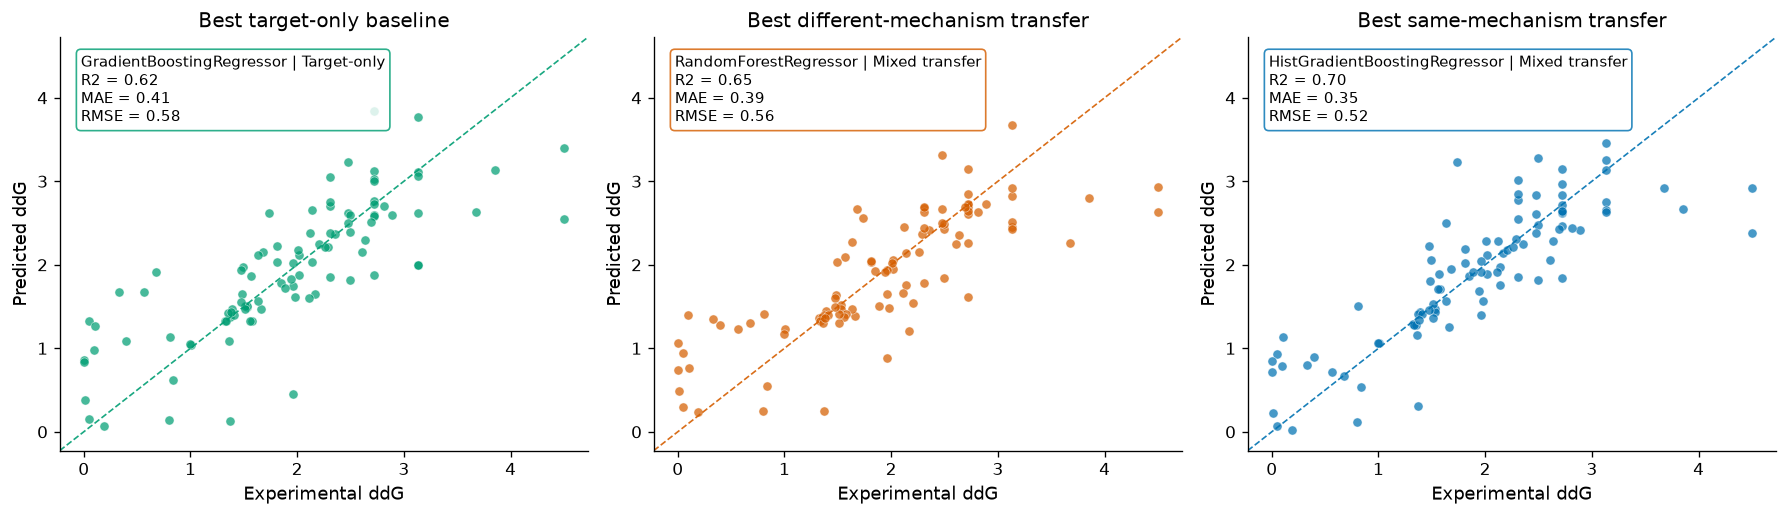

In [7]:
def select_best_score_row(score_long, selection):
    if selection == "baseline":
        sub = score_long.loc[score_long["method_label"].eq("Target-only")].copy()
    elif selection == "same_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Same mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    elif selection == "different_mechanism_transfer":
        sub = score_long.loc[
            score_long["relation_label"].eq("Different mechanism")
            & score_long["method_label"].isin(["Mixed transfer", "Delta learning"])
        ].copy()
    else:
        raise ValueError(selection)

    if len(sub) == 0:
        raise ValueError(f"No rows found for selection={selection!r}")
    return sub.sort_values("R2", ascending=False).iloc[0]


# Keep the presentation order consistent across all figures:
# Target-only -> Different-mechanism transfer -> Same-mechanism transfer.
# The point colors follow the same green / orange / blue scheme used elsewhere.
PARITY_SELECTION_STYLES = OrderedDict(
    [
        (
            "baseline",
            {
                "display_name": "Best target-only baseline",
                "point_color": "#009E73",
            },
        ),
        (
            "different_mechanism_transfer",
            {
                "display_name": "Best different-mechanism transfer",
                "point_color": "#D55E00",
            },
        ),
        (
            "same_mechanism_transfer",
            {
                "display_name": "Best same-mechanism transfer",
                "point_color": "#0072B2",
            },
        ),
    ]
)


SELECTED_ROWS = []
for selection, style in PARITY_SELECTION_STYLES.items():
    row = select_best_score_row(MULTI_MODEL_SCORE_LONG, selection)
    item = row.to_dict()
    item["display_name"] = style["display_name"]
    item["selection"] = selection
    item["point_color"] = style["point_color"]
    SELECTED_ROWS.append(item)

SELECTED_OUTCOME_DF = pd.DataFrame(SELECTED_ROWS)
SELECTED_OUTCOME_DF.to_csv(
    TABLE_DIR / "spoc_selected_best_outcomes_for_parity.csv", index=False
)
display(SELECTED_OUTCOME_DF)


def get_oof_predictions_for_selected(row):
    mask = (
        MULTI_MODEL_OOF_DF["model"].eq(row["model"])
        & MULTI_MODEL_OOF_DF["task_id"].eq(row["task_id"])
        & MULTI_MODEL_OOF_DF["method_label"].eq(row["method_label"])
    )
    pred = MULTI_MODEL_OOF_DF.loc[mask].copy()
    if len(pred) == 0:
        raise ValueError(
            f"Cannot find OOF predictions for selected outcome: {row.to_dict()}"
        )
    return pred


def metrics_from_prediction_df(pred):
    return pooled_metrics(
        pred["y_true"].to_numpy(),
        pred["y_pred"].to_numpy(),
    )


def plot_parity_panel(ax, pred, title, subtitle, point_color):
    y_true = pred["y_true"].to_numpy(dtype=float)
    y_pred = pred["y_pred"].to_numpy(dtype=float)
    metric = metrics_from_prediction_df(pred)

    ax.scatter(
        y_true,
        y_pred,
        s=30,
        alpha=0.72,
        color=point_color,
        edgecolors="white",
        linewidths=0.35,
    )

    finite = np.isfinite(y_true) & np.isfinite(y_pred)
    if finite.any():
        lo = float(np.nanmin([y_true[finite].min(), y_pred[finite].min()]))
        hi = float(np.nanmax([y_true[finite].max(), y_pred[finite].max()]))
        pad = 0.05 * (hi - lo) if hi > lo else 0.5
        lo -= pad
        hi += pad

        ax.plot(
            [lo, hi],
            [lo, hi],
            linestyle="--",
            linewidth=1.0,
            color=point_color,
            alpha=0.9,
        )
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    ax.set_xlabel("Experimental ddG")
    ax.set_ylabel("Predicted ddG")
    ax.set_title(title)
    ax.text(
        0.04,
        0.96,
        subtitle
        + f"\nR2 = {metric['R2']:.2f}"
        + f"\nMAE = {metric['MAE']:.2f}"
        + f"\nRMSE = {metric['RMSE']:.2f}",
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=9,
        bbox={
            "boxstyle": "round,pad=0.3",
            "facecolor": "white",
            "alpha": 0.82,
            "edgecolor": point_color,
        },
    )


fig, axes = plt.subplots(
    1,
    len(SELECTED_OUTCOME_DF),
    figsize=(5.0 * len(SELECTED_OUTCOME_DF), 4.4),
)
if len(SELECTED_OUTCOME_DF) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, SELECTED_OUTCOME_DF.iterrows()):
    pred = get_oof_predictions_for_selected(row)
    subtitle = f"{row['model']} | {row['method_label']}"
    plot_parity_panel(
        ax,
        pred,
        row["display_name"],
        subtitle,
        row["point_color"],
    )

fig.tight_layout()
fig.savefig(FIG_DIR / "spoc_selected_best_parity_plots.svg", bbox_inches="tight")
plt.show()


## Outputs

Main outputs are saved under:

- `results/1_2_spoc_mechanism_transfer/tables/`
- `results/1_2_spoc_mechanism_transfer/figures/`
- `results/1_2_spoc_mechanism_transfer/feature_cache/`

Streamlined output policy:
- `feature_cache/` writes only `spoc_official_like_feature_matrix.npy`.
- `figures/` writes SVG files only.
- model-parameter audit, domain-summary, and error CSV side files are no longer written.

This notebook only benchmarks transfer performance. Direct similarity and anchor-relative manifold analyses should be run in the subsequent mechanism-explanation notebooks.


## 6. Split-seed landscape diagnostic

To avoid a hand-picked subset of validation splits, this diagnostic traverses all target-domain 5-fold split seeds from 0 to 100. The selected same-mechanism and different-mechanism transfer outcomes from the main benchmark are kept fixed, and only the target-domain split seed is varied.

The section writes one lean metrics table and one diagnostic figure. The plotted quantity is ΔR² = same-mechanism transfer − different-mechanism transfer, with the main benchmark split seed marked by a star.


Loaded cached SPOC features: (2132, 2043)
Feature matrices available for seed-landscape diagnostics: {'ru_ahk_inner': (495, 2043), 'ru_ahk_outer': (1539, 2043), 'ru_aho_inner': (98, 2043)}
Evaluating split seeds 0–100.
Loaded cached split-seed landscape metrics from /home/syz/ru-mechanism-transfer/results/1_2_spoc_mechanism_transfer/tables/spoc_seed_landscape_metrics.csv


,split_seed,same_model,same_task_id,same_method_label,same_R2,same_MAE,same_RMSE,same_n_test_total,different_model,different_task_id,different_method_label,different_R2,different_MAE,different_RMSE,different_n_test_total,delta_R2_same_minus_different
0,0,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.752212,0.333528,0.470764,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.687458,0.377650,0.528710,98,0.064754
1,1,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.660828,0.387648,0.550773,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.671215,0.394792,0.542274,98,-0.010387
2,2,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.725891,0.345721,0.495136,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.669245,0.385618,0.543896,98,0.056646
3,3,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.717988,0.338929,0.502223,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.705174,0.369156,0.513507,98,0.012815
4,4,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.677799,0.378379,0.536817,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.619478,0.421177,0.583382,98,0.058321
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,96,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.743637,0.320413,0.478840,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.713244,0.354086,0.506429,98,0.030393
97,97,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.722551,0.353696,0.498144,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.651321,0.398807,0.558439,98,0.071230
98,98,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.738862,0.334610,0.483279,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.702537,0.361488,0.515798,98,0.036325
99,99,HistGradientBoostingRegressor,ru_ahk_inner_to_ru_aho_inner,Mixed transfer,0.668298,0.386009,0.544674,98,RandomForestRegressor,ru_ahk_outer_to_ru_aho_inner,Mixed transfer,0.665020,0.388386,0.547359,98,0.003278


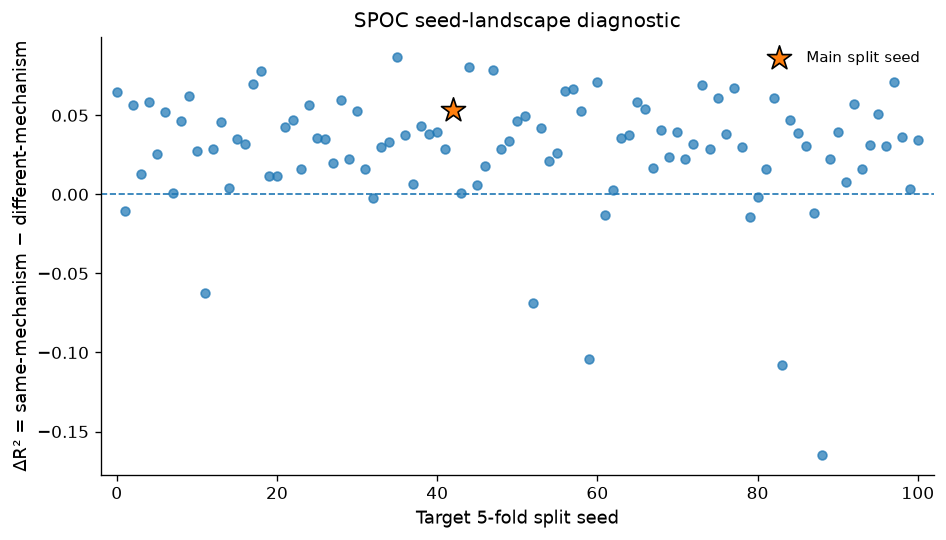

In [8]:
SPLIT_SEED_MIN = 0
SPLIT_SEED_MAX = 100
SPLIT_SEEDS = list(range(SPLIT_SEED_MIN, SPLIT_SEED_MAX + 1))
FORCE_RECOMPUTE_SEED_LANDSCAPE = False

SEED_LANDSCAPE_TABLE = TABLE_DIR / "spoc_seed_landscape_metrics.csv"
SEED_LANDSCAPE_FIG = FIG_DIR / "spoc_seed_landscape_diagnostic.svg"

# Clean verbose outputs from earlier meta-seed / robustness versions.
for obsolete_path in [
    TABLE_DIR / "spoc_meta_seed_generated_split_seeds.csv",
    TABLE_DIR / "spoc_meta_seed_split_validation_metrics.csv",
    TABLE_DIR / "spoc_meta_seed_split_validation_predictions.csv",
    TABLE_DIR / "spoc_selected_outcomes_seed_landscape.csv",
    TABLE_DIR / "spoc_selected_outcomes_seed_landscape_delta_summary.csv",
    TABLE_DIR / "spoc_selected_outcomes_split_seed_robustness.csv",
    FIG_DIR / "spoc_meta_seed_split_validation_boxplot.svg",
    FIG_DIR / "spoc_meta_seed_split_validation_boxplot.png",
    FIG_DIR / "spoc_meta_seed_split_validation_boxplot.pdf",
    FIG_DIR / "spoc_selected_outcomes_seed_landscape_delta_r2.svg",
    FIG_DIR / "spoc_selected_outcomes_split_seed_robustness.svg",
    FIG_DIR / "spoc_selected_outcomes_split_seed_robustness.png",
    FIG_DIR / "spoc_selected_outcomes_split_seed_robustness.pdf",
]:
    if obsolete_path.exists():
        obsolete_path.unlink()


# Make feature matrices available for the split-seed landscape section.
# If the main OOF table was loaded from cache, earlier cells may have skipped feature loading.
def ensure_spoc_features_available():
    """Load or rebuild the SPOC feature matrices needed for split-seed diagnostics."""
    global FEATURES, X_MATRIX, FEATURE_COLUMNS, EXPECTED_FEATURE_COLUMNS, TARGETS, TARGET_META

    required_keys = list(DOMAINS.keys())
    existing_features = globals().get("FEATURES", OrderedDict())
    if isinstance(existing_features, OrderedDict) and all(key in existing_features for key in required_keys):
        FEATURES = existing_features
        TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())
        TARGET_META = OrderedDict(
            (
                key,
                df[["record_id", "reaction_id", "domain_key", "group_key"]].reset_index(drop=True),
            )
            for key, df in DOMAINS.items()
        )
        return

    EXPECTED_FEATURE_COLUMNS = expected_spoc_feature_columns(ALL_DF)
    X_MATRIX, FEATURE_COLUMNS = load_cached_spoc_matrix(EXPECTED_FEATURE_COLUMNS)

    if X_MATRIX is None:
        print("SPOC feature cache is missing or incompatible; rebuilding features for split-seed diagnostics.")
        X_MATRIX, FEATURE_COLUMNS = build_spoc_matrix(ALL_DF)
        if FEATURE_COLUMNS != EXPECTED_FEATURE_COLUMNS:
            raise RuntimeError("Reconstructed SPOC feature columns do not match the expected columns.")
        save_cached_spoc_matrix(X_MATRIX)

    FEATURES = OrderedDict()
    start = 0
    for key, df in DOMAINS.items():
        stop = start + len(df)
        FEATURES[key] = X_MATRIX[start:stop].astype(np.float32, copy=False)
        start = stop

    TARGETS = OrderedDict((key, df[TARGET_COLUMN].to_numpy(dtype=float)) for key, df in DOMAINS.items())
    TARGET_META = OrderedDict(
        (
            key,
            df[["record_id", "reaction_id", "domain_key", "group_key"]].reset_index(drop=True),
        )
        for key, df in DOMAINS.items()
    )


def get_transfer_task_by_id(task_id):
    for task in TRANSFER_TASKS:
        if task["task_id"] == task_id:
            return task
    raise ValueError(f"Unknown transfer task_id: {task_id!r}")


def kfold_splitter_for_seed(y_target, split_seed):
    n_splits = min(int(N_FOLDS), int(len(y_target)))
    if n_splits < 2:
        raise ValueError("The Ru-AHO target domain has too few samples for OOF evaluation.")
    return KFold(n_splits=n_splits, shuffle=True, random_state=int(split_seed))


def run_selected_transfer_for_seed(selected_row, split_seed):
    """Run one fixed transfer outcome under a target-domain split seed."""
    model_key = selected_row["model"]
    method_label = selected_row["method_label"]

    if method_label not in {"Mixed transfer", "Delta learning"}:
        raise ValueError(f"Seed-landscape diagnostics require a transfer outcome, got {method_label!r}.")

    task = get_transfer_task_by_id(selected_row["task_id"])
    x_source = FEATURES[task["source_key"]]
    y_source = TARGETS[task["source_key"]]
    x_target = FEATURES["ru_aho_inner"]
    y_target = TARGETS["ru_aho_inner"]

    cv = kfold_splitter_for_seed(y_target, split_seed)
    source_prior_model = make_model(model_key)
    source_prior_model.fit(x_source, y_source)

    rows = []
    for fold_id, (train_idx, test_idx) in enumerate(cv.split(x_target, y_target), start=1):
        x_train = x_target[train_idx]
        y_train = y_target[train_idx]
        x_test = x_target[test_idx]
        y_test = y_target[test_idx]

        if method_label == "Mixed transfer":
            model = make_model(model_key)
            model.fit(np.vstack([x_source, x_train]), np.concatenate([y_source, y_train]))
            pred = predict_1d(model, x_test)
        elif method_label == "Delta learning":
            delta_model = make_model(model_key)
            source_prior_train = predict_1d(source_prior_model, x_train)
            delta_model.fit(x_train, y_train - source_prior_train)
            pred = predict_1d(source_prior_model, x_test) + predict_1d(delta_model, x_test)

        for local_idx, truth, pred_value in zip(test_idx, y_test, pred):
            rows.append(
                {
                    "split_seed": int(split_seed),
                    "selection": selected_row["selection"],
                    "display_name": selected_row["display_name"],
                    "model": model_key,
                    "task_id": selected_row["task_id"],
                    "relation_label": selected_row["relation_label"],
                    "method_label": method_label,
                    "fold_id": int(fold_id),
                    "target_index": int(local_idx),
                    "y_true": float(truth),
                    "y_pred": float(pred_value),
                }
            )

    return pd.DataFrame(rows)


def selected_row(selection):
    sub = SELECTED_OUTCOME_DF.loc[SELECTED_OUTCOME_DF["selection"].eq(selection)]
    if len(sub) != 1:
        raise ValueError(f"Expected exactly one selected outcome for {selection!r}, found {len(sub)}.")
    return sub.iloc[0]


SAME_MECHANISM_ROW = selected_row("same_mechanism_transfer")
DIFFERENT_MECHANISM_ROW = selected_row("different_mechanism_transfer")


def seed_landscape_cache_is_compatible(path):
    if FORCE_RECOMPUTE_SEED_LANDSCAPE or not path.exists():
        return False
    try:
        cached = pd.read_csv(path)
    except (EmptyDataError, pd.errors.ParserError):
        return False

    required_columns = {
        "split_seed",
        "same_model",
        "same_task_id",
        "same_method_label",
        "different_model",
        "different_task_id",
        "different_method_label",
        "same_R2",
        "different_R2",
        "delta_R2_same_minus_different",
    }
    if not required_columns.issubset(cached.columns):
        return False

    expected_seeds = set(SPLIT_SEEDS)
    observed_seeds = set(cached["split_seed"].astype(int).unique())
    if observed_seeds != expected_seeds:
        return False

    selected_signature_matches = (
        cached["same_model"].astype(str).eq(str(SAME_MECHANISM_ROW["model"])).all()
        and cached["same_task_id"].astype(str).eq(str(SAME_MECHANISM_ROW["task_id"])).all()
        and cached["same_method_label"].astype(str).eq(str(SAME_MECHANISM_ROW["method_label"])).all()
        and cached["different_model"].astype(str).eq(str(DIFFERENT_MECHANISM_ROW["model"])).all()
        and cached["different_task_id"].astype(str).eq(str(DIFFERENT_MECHANISM_ROW["task_id"])).all()
        and cached["different_method_label"].astype(str).eq(str(DIFFERENT_MECHANISM_ROW["method_label"])).all()
    )
    return bool(selected_signature_matches)


ensure_spoc_features_available()
print("Feature matrices available for seed-landscape diagnostics:", {key: FEATURES[key].shape for key in FEATURES})
print(f"Evaluating split seeds {SPLIT_SEED_MIN}–{SPLIT_SEED_MAX}.")

if seed_landscape_cache_is_compatible(SEED_LANDSCAPE_TABLE):
    SEED_LANDSCAPE_DF = pd.read_csv(SEED_LANDSCAPE_TABLE)
    print(f"Loaded cached split-seed landscape metrics from {SEED_LANDSCAPE_TABLE}")
else:
    seed_rows = []
    for split_seed in SPLIT_SEEDS:
        print(f"Split-seed landscape: split_seed={split_seed}")
        same_pred = run_selected_transfer_for_seed(SAME_MECHANISM_ROW, split_seed)
        different_pred = run_selected_transfer_for_seed(DIFFERENT_MECHANISM_ROW, split_seed)

        same_metrics = pooled_metrics(same_pred["y_true"].to_numpy(), same_pred["y_pred"].to_numpy())
        different_metrics = pooled_metrics(
            different_pred["y_true"].to_numpy(),
            different_pred["y_pred"].to_numpy(),
        )

        seed_rows.append(
            {
                "split_seed": int(split_seed),
                "same_model": SAME_MECHANISM_ROW["model"],
                "same_task_id": SAME_MECHANISM_ROW["task_id"],
                "same_method_label": SAME_MECHANISM_ROW["method_label"],
                "same_R2": same_metrics["R2"],
                "same_MAE": same_metrics["MAE"],
                "same_RMSE": same_metrics["RMSE"],
                "same_n_test_total": same_metrics["n_test_total"],
                "different_model": DIFFERENT_MECHANISM_ROW["model"],
                "different_task_id": DIFFERENT_MECHANISM_ROW["task_id"],
                "different_method_label": DIFFERENT_MECHANISM_ROW["method_label"],
                "different_R2": different_metrics["R2"],
                "different_MAE": different_metrics["MAE"],
                "different_RMSE": different_metrics["RMSE"],
                "different_n_test_total": different_metrics["n_test_total"],
                "delta_R2_same_minus_different": same_metrics["R2"] - different_metrics["R2"],
            }
        )

    SEED_LANDSCAPE_DF = pd.DataFrame(seed_rows).sort_values("split_seed").reset_index(drop=True)
    SEED_LANDSCAPE_DF.to_csv(SEED_LANDSCAPE_TABLE, index=False)

display(SEED_LANDSCAPE_DF)

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.scatter(
    SEED_LANDSCAPE_DF["split_seed"],
    SEED_LANDSCAPE_DF["delta_R2_same_minus_different"],
    s=28,
    alpha=0.72,
)
ax.axhline(0.0, linestyle="--", linewidth=1.0)

main_row = SEED_LANDSCAPE_DF.loc[SEED_LANDSCAPE_DF["split_seed"].eq(int(RANDOM_STATE))]
if len(main_row) == 1:
    ax.scatter(
        main_row["split_seed"],
        main_row["delta_R2_same_minus_different"],
        marker="*",
        s=230,
        edgecolors="black",
        linewidths=1.0,
        zorder=4,
        label="Main split seed",
    )
    ax.legend(frameon=False, loc="upper right")

ax.set_xlabel("Target 5-fold split seed")
ax.set_ylabel("ΔR² = same-mechanism − different-mechanism")
ax.set_title("SPOC seed-landscape diagnostic")
ax.set_xlim(SPLIT_SEED_MIN - 2, SPLIT_SEED_MAX + 2)
fig.tight_layout()
fig.savefig(SEED_LANDSCAPE_FIG, bbox_inches="tight")
plt.show()
